# Model Primer v2 — I/O, Preprocessing, Baseline, Metrics

1. Input / output contract
2. Preprocessing pipeline
3. TinyUNet baseline
4. Forward-pass sanity check
5. Training loop
6. Evaluation metrics

Dataset v2 — `status ∈ {ok, warn}` rows of `audit_v2/clean_index.csv`. Native vertebra IDs are 1..17 (T1..L5) — no offset remap needed.

## 0 · Setup

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF


In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2" / "clean_index.csv"
TARGET_IDS_V2 = tuple(range(1, 18))  # v2 label space: T1..L5 with IDs 1..17
IMG_H, IMG_W = 512, 256

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}\ntarget_size={IMG_H}x{IMG_W}")


repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42
target_size=512x256


In [3]:
from ai.evaluation.cobb import cobb_from_segmentation
from ai.preprocessing.keypoints import multiclass_mask_to_keypoints
from ai.preprocessing.segmentation import NUM_SEG_CLASSES, remap_to_target_classes


In [4]:
def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run data_exploration.ipynb first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["status"].isin(["ok", "warn"])].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)}  train={len(TRAIN_DF)}  val={len(VAL_DF)}")
TRAIN_DF.head(3)

total=250  trainable=152  train=122  val=30


,patient_id,category,image_path,binary_mask_path,multiclass_mask_path,curve_csv_path,overlay_path,image_h,image_w,cobb_angle_deg,target_vertebrae_count,target_vertebrae_present,status,issues
0,100,Scoliosis,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,970.0,594.0,85.64864,15,"T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L3,L4,L5",warn,NaN
1,30,Normal,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,NaN,NaN,846.0,201.0,NaN,14,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2",warn,NaN
2,23,Normal,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,NaN,NaN,878.0,241.0,NaN,16,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",warn,NaN


## 1 · Input / Output Contract

Raw inputs from disk, derived supervision targets for both task families (segmentation and keypoints), and the tensor shapes the model will see.

In [5]:
def read_gray(path: Path) -> np.ndarray:
    with Image.open(path) as im:
        return np.array(im.convert("L"), dtype=np.uint8)

def read_mask(path: Path) -> np.ndarray:
    with Image.open(path) as im:
        return np.array(im, dtype=np.uint8)

def pick_sample(df: pd.DataFrame, status: str = "ok") -> pd.Series:
    return df[df["status"] == status].iloc[0]

In [6]:
sample = pick_sample(TRAINABLE, "ok")
raw_image = read_gray(Path(sample["image_path"]))
raw_mask  = read_mask(Path(sample["multiclass_mask_path"]))

seg_target = remap_to_target_classes(raw_mask, target_ids=TARGET_IDS_V2)  # (H, W) uint8, values 0..17
kps_target = multiclass_mask_to_keypoints(raw_mask, target_ids=TARGET_IDS_V2)  # (68, 2) float, NaN-padded

print(f"raw_image   shape={raw_image.shape} dtype={raw_image.dtype}")
print(f"raw_mask    shape={raw_mask.shape}  dtype={raw_mask.dtype}  unique_ids={sorted(np.unique(raw_mask).tolist())[:8]}...")
print(f"seg_target  shape={seg_target.shape} dtype={seg_target.dtype} classes={sorted(np.unique(seg_target).tolist())}")
print(f"kps_target  shape={kps_target.shape} dtype={kps_target.dtype} finite={int(np.isfinite(kps_target).all(axis=1).sum())}/68")

raw_image   shape=(971, 259) dtype=uint8
raw_mask    shape=(971, 259)  dtype=uint8  unique_ids=[0, 1, 2, 3, 4, 5, 6, 7]...
seg_target  shape=(971, 259) dtype=uint8 classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
kps_target  shape=(68, 2) dtype=float64 finite=68/68


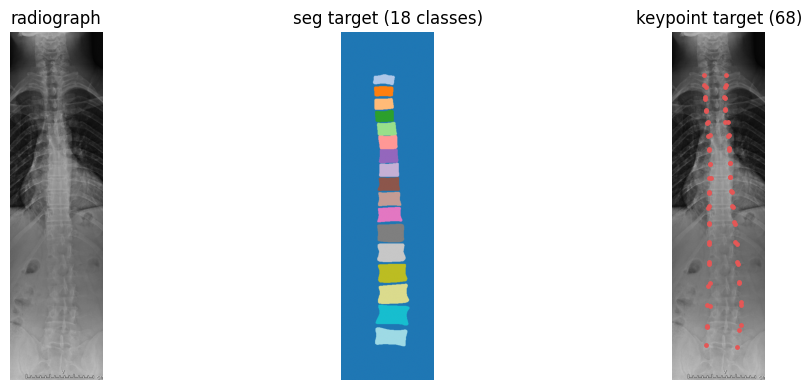

In [7]:
def overlay_keypoints(ax, image: np.ndarray, kps: np.ndarray) -> None:
    ax.imshow(image, cmap="gray")
    finite = np.isfinite(kps).all(axis=1)
    ax.scatter(kps[finite, 0], kps[finite, 1], s=6, c="#e45756")
    ax.set_axis_off()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw_image, cmap="gray"); axes[0].set_title("radiograph"); axes[0].set_axis_off()
axes[1].imshow(seg_target, cmap="tab20"); axes[1].set_title("seg target (18 classes)"); axes[1].set_axis_off()
overlay_keypoints(axes[2], raw_image, kps_target); axes[2].set_title("keypoint target (68)")
plt.tight_layout(); plt.show()

**Contract (post-resize to 256×512):**

| Tensor | Shape | Dtype | Role | Meaning |
|---|---|---|---|---|
| `image` | `(1, 256, 512)` | `float32` | input | grayscale radiograph, normalized to `[0, 1]` |
| `seg`   | `(256, 512)`    | `int64`   | target + model output | per-pixel class label, `0=bg, 1..17=T1..L5` |

Segmentation-only model: weighted CE + soft Dice combo loss. Cobb angle derived from predicted segmentation mask via `cobb_from_segmentation`.


## 2 · Preprocessing Pipeline

In [8]:
def resize_image(arr: np.ndarray, h: int, w: int) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((w, h), Image.BILINEAR), dtype=np.uint8)

def resize_mask(arr: np.ndarray, h: int, w: int) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((w, h), Image.NEAREST), dtype=np.uint8)

def normalize_image(arr: np.ndarray) -> np.ndarray:
    return arr.astype(np.float32) / 255.0

def to_image_tensor(arr: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(arr).unsqueeze(0)  # (1, H, W)

def to_seg_tensor(arr: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(arr.astype(np.int64))

def to_kps_tensor(arr: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(arr.astype(np.float32))

In [9]:
def preprocess_case(row: pd.Series, h: int = IMG_H, w: int = IMG_W) -> dict[str, torch.Tensor]:
    image_np = resize_image(read_gray(Path(row["image_path"])), h, w)
    mask_np  = resize_mask(read_mask(Path(row["multiclass_mask_path"])), h, w)
    seg_np   = remap_to_target_classes(mask_np, target_ids=TARGET_IDS_V2)
    kps_np   = multiclass_mask_to_keypoints(mask_np, target_ids=TARGET_IDS_V2)
    return {
        "image": to_image_tensor(normalize_image(image_np)),
        "seg":   to_seg_tensor(seg_np),
        "kps":   to_kps_tensor(kps_np),
    }

In [10]:
for i in range(3):
    c = preprocess_case(TRAINABLE.iloc[i])
    print(f"case {i}: image={tuple(c['image'].shape)} {c['image'].dtype}  seg={tuple(c['seg'].shape)} {c['seg'].dtype}  kps={tuple(c['kps'].shape)} {c['kps'].dtype}")

case 0: image=(1, 512, 256) torch.float32  seg=(512, 256) torch.int64  kps=(68, 2) torch.float32
case 1: image=(1, 512, 256) torch.float32  seg=(512, 256) torch.int64  kps=(68, 2) torch.float32
case 2: image=(1, 512, 256) torch.float32  seg=(512, 256) torch.int64  kps=(68, 2) torch.float32


In [11]:
def _uniform(lo: float, hi: float) -> float:
    return float(torch.empty(1).uniform_(lo, hi).item())

def augment_case(image: torch.Tensor, seg: torch.Tensor
                 ) -> tuple[torch.Tensor, torch.Tensor]:
    if torch.rand(1).item() < 0.5:   # small affine
        angle = _uniform(-5.0, 5.0)
        tx = _uniform(-0.05, 0.05) * IMG_W
        ty = _uniform(-0.05, 0.05) * IMG_H
        scale = _uniform(0.9, 1.1)
        image = TF.affine(image, angle=angle, translate=[tx, ty], scale=scale,
                          shear=[0.0], interpolation=TF.InterpolationMode.BILINEAR)
        seg_3d = seg.unsqueeze(0).float()
        seg_3d = TF.affine(seg_3d, angle=angle, translate=[tx, ty], scale=scale,
                           shear=[0.0], interpolation=TF.InterpolationMode.NEAREST)
        seg = seg_3d.squeeze(0).long()
    if torch.rand(1).item() < 0.5:   # intensity jitter
        gain = _uniform(0.8, 1.2)
        bias = _uniform(-0.1, 0.1)
        image = (image * gain + bias).clamp(0.0, 1.0)
    return image, seg

class SpineDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> tuple[torch.Tensor, torch.Tensor]:
        case = preprocess_case(self.df.iloc[i])
        image, seg = case["image"], case["seg"]
        if self.augment:
            image, seg = augment_case(image, seg)
        return image, seg

SpineSegDataset = SpineDataset   # legacy alias


## 3 · TinyUNet Baseline

5-level encoder, `base=32` channels, segmentation-only. ~7.8M params.


In [12]:
def conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

def down(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(nn.MaxPool2d(2), conv_block(in_ch, out_ch))

class Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        return self.conv(torch.cat([x, skip], dim=1))

In [13]:
class TinyUNet(nn.Module):
    def __init__(self, in_ch: int = 1, num_classes: int = NUM_SEG_CLASSES, base: int = 32):
        super().__init__()
        self.inc = conv_block(in_ch, base)
        self.d1 = down(base,      base * 2)
        self.d2 = down(base * 2,  base * 4)
        self.d3 = down(base * 4,  base * 8)
        self.d4 = down(base * 8,  base * 16)
        self.u1 = Up(base * 16, base * 8, base * 8)
        self.u2 = Up(base * 8,  base * 4, base * 4)
        self.u3 = Up(base * 4,  base * 2, base * 2)
        self.u4 = Up(base * 2,  base,     base)
        self.seg_head = nn.Conv2d(base, num_classes, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x0 = self.inc(x)
        x1 = self.d1(x0)
        x2 = self.d2(x1)
        x3 = self.d3(x2)
        x4 = self.d4(x3)
        y  = self.u1(x4, x3)
        y  = self.u2(y,  x2)
        y  = self.u3(y,  x1)
        y  = self.u4(y,  x0)
        return self.seg_head(y)


In [14]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

model = TinyUNet().to(DEVICE)
print(f"TinyUNet params: {count_params(model):,}")

TinyUNet params: 7,765,970


Dropped Escape call with ulEscapeCode : 0x03007703


## 4 · Forward-Pass Sanity Check

In [15]:
def predict_one(model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    """Returns (H, W) int64 predicted segmentation."""
    model.eval()
    with torch.no_grad():
        seg_logits = model(image.unsqueeze(0).to(DEVICE))
    return seg_logits.argmax(dim=1).squeeze(0).cpu()

case = preprocess_case(TRAINABLE.iloc[0])
seg_pred = predict_one(model, case["image"])
print(f"seg  shape={tuple(seg_pred.shape)} dtype={seg_pred.dtype} unique={sorted(torch.unique(seg_pred).tolist())[:6]}...")


seg  shape=(512, 256) dtype=torch.int64 unique=[14]...


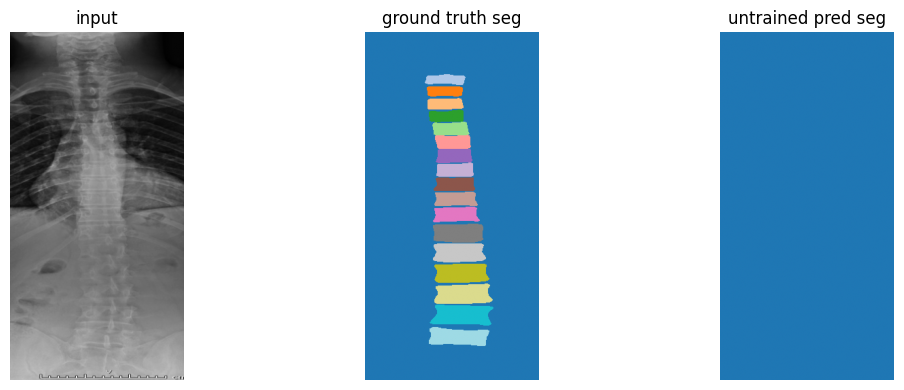

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input"); axes[0].set_axis_off()
axes[1].imshow(case["seg"], cmap="tab20");             axes[1].set_title("ground truth seg"); axes[1].set_axis_off()
axes[2].imshow(seg_pred, cmap="tab20");                axes[2].set_title("untrained pred seg"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()


## 5 · Training Loop

One epoch over `TRAIN_DF` (80% of audit-clean rows). `VAL_DF` holds the remaining 20% for §6.

In [17]:
import time

CLASS_WEIGHTS = torch.tensor([0.1] + [1.0] * (NUM_SEG_CLASSES - 1), device=DEVICE)

def soft_dice_loss(logits: torch.Tensor, target: torch.Tensor,
                   num_classes: int, eps: float = 1e-6) -> torch.Tensor:
    probs  = F.softmax(logits, dim=1)
    # Manual one-hot — F.one_hot unsupported on DirectML
    onehot = torch.zeros_like(probs)
    onehot.scatter_(1, target.unsqueeze(1), 1.0)
    probs, onehot = probs[:, 1:], onehot[:, 1:]
    dims = (0, 2, 3)
    intersect   = (probs * onehot).sum(dim=dims)
    cardinality = probs.sum(dim=dims) + onehot.sum(dim=dims)
    dice = (2.0 * intersect + eps) / (cardinality + eps)
    return 1.0 - dice.mean()

def seg_loss_fn(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    ce   = F.cross_entropy(logits, target, weight=CLASS_WEIGHTS)
    dice = soft_dice_loss(logits, target, NUM_SEG_CLASSES)
    return 0.3 * ce + 0.7 * dice

def train_step(model: nn.Module,
               batch: tuple[torch.Tensor, torch.Tensor],
               optimizer: torch.optim.Optimizer) -> float:
    images, seg_t = [t.to(DEVICE) for t in batch]
    seg_logits = model(images)
    loss = seg_loss_fn(seg_logits, seg_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return float(loss.item())

def run_epoch(model: nn.Module, loader: DataLoader,
              optimizer: torch.optim.Optimizer) -> np.ndarray:
    model.train()
    return np.array([train_step(model, b, optimizer) for b in loader])

@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card  = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    for batch in loader:
        images, seg_t = [t.to(DEVICE) for t in batch]
        seg_logits = model(images)
        total_loss += float(seg_loss_fn(seg_logits, seg_t))
        pred_mask = seg_logits.argmax(dim=1)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1]  += p.sum() + g.sum()
    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid = card > 0
    return {
        "loss": total_loss / max(1, len(loader)),
        "dice": float(dice_per_cls[valid].mean()) if valid.any() else float("nan"),
    }


In [ ]:
NUM_EPOCHS = 80
BATCH_SIZE = 4
LR = 1e-3

model = TinyUNet().to(DEVICE)
print(f"TinyUNet params: {count_params(model):,}")

train_loader = DataLoader(SpineDataset(TRAIN_DF, augment=True),  batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SpineDataset(VAL_DF,   augment=False), batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

history: list[dict[str, float]] = []
best_dice = -1.0
best_state: dict[str, torch.Tensor] | None = None

t_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_losses = run_epoch(model, train_loader, optimizer)
    val_stats = validate(model, val_loader)
    scheduler.step(val_stats["loss"])
    row = {
        "epoch":      epoch,
        "train_loss": float(train_losses.mean()),
        "val_loss":   val_stats["loss"],
        "val_dice":   val_stats["dice"],
        "lr":         float(optimizer.param_groups[0]["lr"]),
        "sec":        time.time() - t0,
    }
    history.append(row)
    if val_stats["dice"] > best_dice:
        best_dice = val_stats["dice"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch:2d}/{NUM_EPOCHS}  "
          f"train={row['train_loss']:.3f}  val={row['val_loss']:.3f}  "
          f"dice={row['val_dice']:.3f}  lr={row['lr']:.1e}  ({row['sec']:.1f}s)")

if best_state is not None:
    model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print(f"\ntotal time: {time.time() - t_start:.1f}s  best val_dice={best_dice:.3f}")

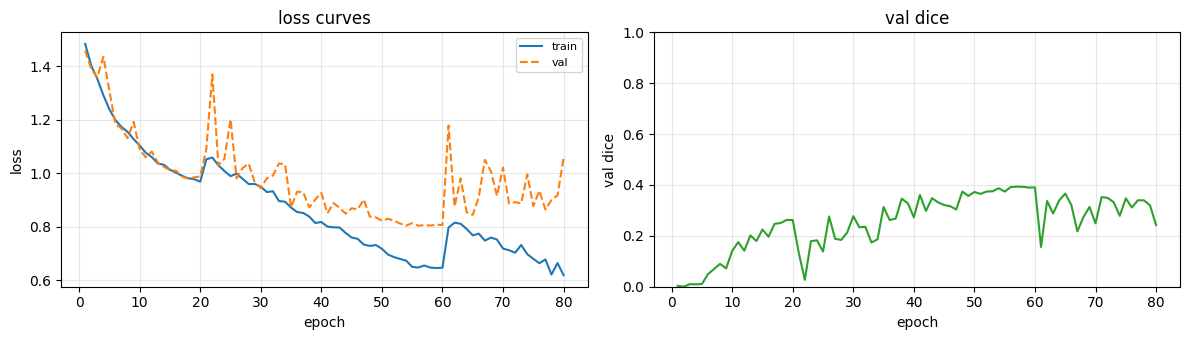

In [19]:
fig, (ax_loss, ax_dice) = plt.subplots(1, 2, figsize=(12, 3.5))

ax_loss.plot(history_df["epoch"], history_df["train_loss"], label="train", linewidth=1.5)
ax_loss.plot(history_df["epoch"], history_df["val_loss"],   label="val",   linewidth=1.5, linestyle="--")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("loss"); ax_loss.set_title("loss curves")
ax_loss.legend(fontsize=8); ax_loss.grid(alpha=0.3)

ax_dice.plot(history_df["epoch"], history_df["val_dice"], color="tab:green", linewidth=1.5)
ax_dice.set_xlabel("epoch"); ax_dice.set_ylabel("val dice")
ax_dice.set_title("val dice"); ax_dice.set_ylim(0, 1); ax_dice.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 6 · Evaluation Metrics

### 6.1 · Segmentation — per-class Dice / IoU / HD95

**Dice** per class equals **pixel F1**: $2 \cdot TP / (2 \cdot TP + FP + FN)$. Mean Dice averages over the 17 vertebra classes (background excluded).

**IoU (Jaccard)** per class: $TP / (TP + FP + FN)$. Monotonic with Dice ($IoU = Dice / (2 - Dice)$) but reported alongside it in every benchmark (nnU-Net, AASCE, BraTS).

**HD95** — 95th-percentile symmetric Hausdorff distance in pixels. Boundary-aware: catches bad contours where Dice still looks fine (e.g. volume matches but edges are jagged).

### 6.2 · Cobb angle — MAE / SMAPE / Pearson r

**MAE**: mean absolute error in degrees, per-case then averaged.

**SMAPE**: $|pred - gt| / ((|pred| + |gt|) / 2)$ — the AASCE challenge scoring metric. Symmetric and scale-free.

**Pearson r**: set-level correlation between predicted and ground-truth angles. MAE tells you how wrong on average; r tells you whether the model *tracks* severity at all.

### 6.3 · Severity — accuracy / macro-F1 / Cohen's κ / confusion matrix

Buckets: `normal <10° · mild 10–25° · moderate 25–40° · severe ≥40°`.

**Accuracy**: fraction of correctly bucketed cases.

**Macro-F1**: mean of per-class F1 over the four buckets. Penalizes the model for ignoring minority classes (severe cases are rare).

**Cohen's κ**: chance-corrected agreement — the clinical standard for inter-rater reliability. $\kappa = 1$ perfect, $\kappa = 0$ no better than chance.

**Confusion matrix**: which buckets get confused with which.

In [20]:
from scipy.ndimage import distance_transform_edt

def dice_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        p, g = pred == c, target == c
        denom = p.sum() + g.sum()
        if denom > 0:
            scores[c] = 2.0 * (p & g).sum() / denom
    return scores

def iou_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        p, g = pred == c, target == c
        union = (p | g).sum()
        if union > 0:
            scores[c] = (p & g).sum() / union
    return scores

def _hd95_binary(p: np.ndarray, g: np.ndarray) -> float:
    if not p.any() or not g.any():
        return float("nan")
    d_pg = distance_transform_edt(~g)[p]
    d_gp = distance_transform_edt(~p)[g]
    return float(max(np.percentile(d_pg, 95), np.percentile(d_gp, 95)))

def hd95_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    p_np, g_np = pred.numpy(), target.numpy()
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        scores[c] = _hd95_binary(p_np == c, g_np == c)
    return scores

def _mean_targets(per_class: torch.Tensor) -> float:
    targets = per_class[1:]
    valid = ~torch.isnan(targets)
    return float(targets[valid].mean()) if valid.any() else float("nan")

def mean_dice_targets(pred, target): return _mean_targets(dice_per_class(pred, target, NUM_SEG_CLASSES))
def mean_iou_targets(pred, target):  return _mean_targets(iou_per_class(pred, target, NUM_SEG_CLASSES))
def mean_hd95_targets(pred, target): return _mean_targets(hd95_per_class(pred, target, NUM_SEG_CLASSES))

In [21]:
SEVERITY_BUCKETS = (("normal", 0.0, 10.0), ("mild", 10.0, 25.0),
                    ("moderate", 25.0, 40.0), ("severe", 40.0, 999.0))
SEVERITY_LABELS = [name for name, _, _ in SEVERITY_BUCKETS]

def severity_bucket(angle: float) -> str:
    for name, lo, hi in SEVERITY_BUCKETS:
        if lo <= angle < hi:
            return name
    return "unknown"

def smape(pred: float, gt: float) -> float:
    denom = (abs(pred) + abs(gt)) / 2.0
    return abs(pred - gt) / denom if denom > 0 else float("nan")

In [22]:
def evaluate_case(model: nn.Module, row: pd.Series) -> dict[str, float]:
    case = preprocess_case(row)
    seg_pred = predict_one(model, case["image"])
    out: dict[str, float] = {
        "mean_dice": mean_dice_targets(seg_pred, case["seg"]),
        "mean_iou":  mean_iou_targets(seg_pred, case["seg"]),
        "mean_hd95": mean_hd95_targets(seg_pred, case["seg"]),
    }
    gt_deg = row.get("cobb_angle_deg")
    if pd.notna(gt_deg):
        pred_deg = cobb_from_segmentation(seg_pred.numpy())
        if np.isfinite(pred_deg):
            out["cobb_pred"]     = float(pred_deg)
            out["cobb_true"]     = float(gt_deg)
            out["cobb_abs_err"]  = abs(pred_deg - float(gt_deg))
            out["cobb_smape"]    = smape(pred_deg, float(gt_deg))
            out["severity_pred"] = severity_bucket(pred_deg)
            out["severity_true"] = severity_bucket(float(gt_deg))
    return out

def evaluate_set(model: nn.Module, df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame([evaluate_case(model, r) for _, r in df.iterrows()])


In [23]:
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix

def summarize(eval_df: pd.DataFrame) -> dict[str, float]:
    cobb_mask = eval_df["cobb_true"].notna() if "cobb_true" in eval_df else pd.Series(dtype=bool)
    has_cobb = bool(cobb_mask.any())
    summary: dict[str, float] = {
        "n_cases": float(len(eval_df)),
        "dice":    float(eval_df["mean_dice"].mean()),
        "iou":     float(eval_df["mean_iou"].mean()),
        "hd95_px": float(eval_df["mean_hd95"].mean(skipna=True)),
    }
    if has_cobb:
        sub = eval_df[cobb_mask]
        summary["cobb_mae"]   = float(sub["cobb_abs_err"].mean())
        summary["cobb_smape"] = float(sub["cobb_smape"].mean())
        summary["cobb_r"]     = float(sub[["cobb_pred", "cobb_true"]].corr().iloc[0, 1])
        y_true, y_pred = sub["severity_true"], sub["severity_pred"]
        summary["sev_acc"]      = float((y_true == y_pred).mean())
        summary["sev_macro_f1"] = float(f1_score(y_true, y_pred, labels=SEVERITY_LABELS, average="macro", zero_division=0))
        summary["sev_kappa"]    = float(cohen_kappa_score(y_true, y_pred, labels=SEVERITY_LABELS))
    return summary

eval_df = evaluate_set(model, VAL_DF)
stats   = summarize(eval_df)
print(f"evaluated {int(stats['n_cases'])} held-out cases\n")
for k, v in stats.items():
    if k == "n_cases": continue
    print(f"  {k:14s} {v:7.3f}")

cobb_rows = eval_df[eval_df["cobb_true"].notna()] if "cobb_true" in eval_df else eval_df.iloc[0:0]
if len(cobb_rows):
    cm = confusion_matrix(cobb_rows["severity_true"], cobb_rows["severity_pred"], labels=SEVERITY_LABELS)
    print(f"\nseverity confusion matrix  (n={len(cobb_rows)}, rows=true, cols=pred)")
    print(pd.DataFrame(cm, index=SEVERITY_LABELS, columns=SEVERITY_LABELS))
else:
    print("\nno cobb-annotated cases in VAL_DF \u2014 severity matrix skipped")


evaluated 30 held-out cases

  dice             0.374
  iou              0.274
  hd95_px         31.698
  cobb_mae        13.270
  cobb_smape       0.232
  cobb_r           0.587
  sev_acc          0.786
  sev_macro_f1     0.229
  sev_kappa        0.160

severity confusion matrix  (n=14, rows=true, cols=pred)
          normal  mild  moderate  severe
normal         0     0         0       0
mild           0     0         0       0
moderate       0     1         0       1
severe         0     0         1      11


### 6.4 · Qualitative check on a held-out case


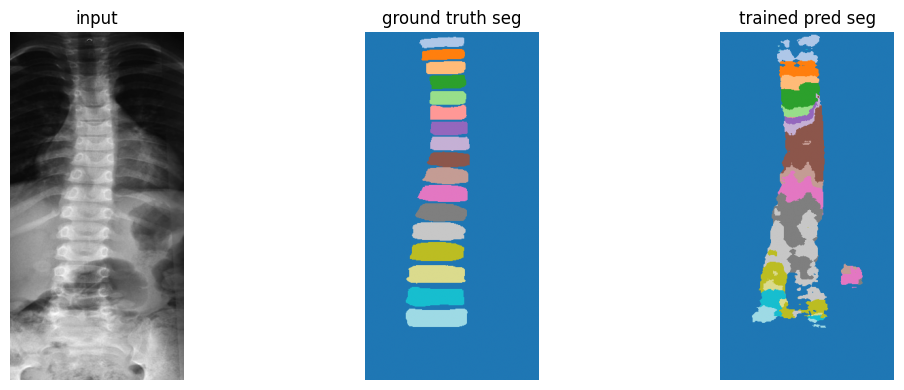

In [24]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
seg_pred = predict_one(model, case["image"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input"); axes[0].set_axis_off()
axes[1].imshow(case["seg"], cmap="tab20");             axes[1].set_title("ground truth seg"); axes[1].set_axis_off()
axes[2].imshow(seg_pred, cmap="tab20");                axes[2].set_title("trained pred seg"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()


## 7 · Summary

- **Input contract:** `(1, 256, 512) float32` normalized radiograph.
- **Seg output:** `(18, 256, 512) float32` logits → `(256, 512) int64` argmax.
- **Augmentation:** random affine (±5° rotation, ±5% translate, 0.9–1.1 scale) + intensity jitter, train only.
- **Architecture:** TinyUNet, 5-level encoder, `base=32`, segmentation-only head.
- **Loss:** `0.3 · weighted CE + 0.7 · soft Dice` with bg weight 0.1.
- **Training:** Adam + `ReduceLROnPlateau` on val loss, 80 epochs, best-checkpoint restored at end.
- **Cobb angle:** derived from predicted segmentation mask via `cobb_from_segmentation`.
- **Metrics:** mean Dice / IoU / HD95 (seg), Cobb MAE / SMAPE / r, severity accuracy / macro-F1 / Cohen's κ.
